## Data Loading and Initial Look

In [26]:
#Importing data and making sure it prints properly
import pandas as pd
import numpy as np
from IPython.display import HTML, display
import tabulate

df = pd.read_csv('mushrooms.csv')
df

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


In [27]:
# Basic info
print('BASIC INFORMATION')
print('='*60)

print(f"DATASET SHAPE: {df.shape}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print('='*60)
print("COLUMN NAMES:")
print(df.columns.tolist())

print('='*60)
print("DATA TYPES:")
print(df.dtypes)

print('='*60)
print("Missing values per column:")
print(df.isnull().sum())

BASIC INFORMATION
DATASET SHAPE: (8124, 23)
Rows: 8124
Columns: 23
COLUMN NAMES:
['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']
DATA TYPES:
class                       object
cap-shape                   object
cap-surface                 object
cap-color                   object
bruises                     object
odor                        object
gill-attachment             object
gill-spacing                object
gill-size                   object
gill-color                  object
stalk-shape                 object
stalk-root                  object
stalk-surface-above-ring    object
stalk-surface-below-ring    object
stalk-color-above-ring      object
stalk-color-

In [28]:
# Check for '?' values (which represent missing in this dataset)
print("Checking for '?' values (missing data encoding):")
for col in df.columns:
    question_marks = (df[col] == '?').sum()
    if question_marks > 0:
        print(f"{col}: {question_marks} '?' values")

Checking for '?' values (missing data encoding):
stalk-root: 2480 '?' values


In [29]:
# Quick look at unique values per feature
print("Number of unique values per feature:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Number of unique values per feature:
class: 2 unique values
cap-shape: 6 unique values
cap-surface: 4 unique values
cap-color: 10 unique values
bruises: 2 unique values
odor: 9 unique values
gill-attachment: 2 unique values
gill-spacing: 2 unique values
gill-size: 2 unique values
gill-color: 12 unique values
stalk-shape: 2 unique values
stalk-root: 5 unique values
stalk-surface-above-ring: 4 unique values
stalk-surface-below-ring: 4 unique values
stalk-color-above-ring: 9 unique values
stalk-color-below-ring: 9 unique values
veil-type: 1 unique values
veil-color: 4 unique values
ring-number: 3 unique values
ring-type: 5 unique values
spore-print-color: 9 unique values
population: 6 unique values
habitat: 7 unique values


In [30]:
#Putting all of that information into a table:

In [31]:
feature_data = []
for col in df.columns:
    if col == "class":
        continue
    n_unique = df[col].nunique()
    unique_vals = ", ".join(sorted(df[col].unique()))
    n_missing = (df[col] == "?").sum()
    feature_data.append((col, "categorical", n_unique, unique_vals, n_missing))

display(HTML(tabulate.tabulate(feature_data, tablefmt="html",
                               headers=["Feature", "Type", "N Unique", "Values", "Missing"])))

Feature,Type,N Unique,Values,Missing
cap-shape,categorical,6,"b, c, f, k, s, x",0
cap-surface,categorical,4,"f, g, s, y",0
cap-color,categorical,10,"b, c, e, g, n, p, r, u, w, y",0
bruises,categorical,2,"f, t",0
odor,categorical,9,"a, c, f, l, m, n, p, s, y",0
gill-attachment,categorical,2,"a, f",0
gill-spacing,categorical,2,"c, w",0
gill-size,categorical,2,"b, n",0
gill-color,categorical,12,"b, e, g, h, k, n, o, p, r, u, w, y",0
stalk-shape,categorical,2,"e, t",0


In [32]:
# Check class balance and features with only one feature
class_counts = df["class"].value_counts()
print("Class distribution:")
print(f"  Edible (e):    {class_counts['e']} ({100*class_counts['e']/len(df):.1f}%)")
print(f"  Poisonous (p): {class_counts['p']} ({100*class_counts['p']/len(df):.1f}%)")

print("\nFeatures with only 1 unique value:")
for col in df.columns:
    if df[col].nunique() == 1:
        print(col, "->", df[col].unique())

Class distribution:
  Edible (e):    4208 (51.8%)
  Poisonous (p): 3916 (48.2%)

Features with only 1 unique value:
veil-type -> ['p']


In [33]:
# Note on outliers: since all features are categorical,
# there are no numerical outliers to check for in this dataset
# The only inconsistency is stalk-root which uses '?' for missing values which will be handled during cleaning

## Data Visualization

In [34]:
# Separate into edible and poisonous for plotting
# Since all features are categorical, use bar charts instead of histograms
import matplotlib.pyplot as plt
import math
%matplotlib inline

df_edible    = df[df["class"] == "e"]
df_poisonous = df[df["class"] == "p"]

print("Edible:   ", len(df_edible))
print("Poisonous:", len(df_poisonous))

Edible:    4208
Poisonous: 3916


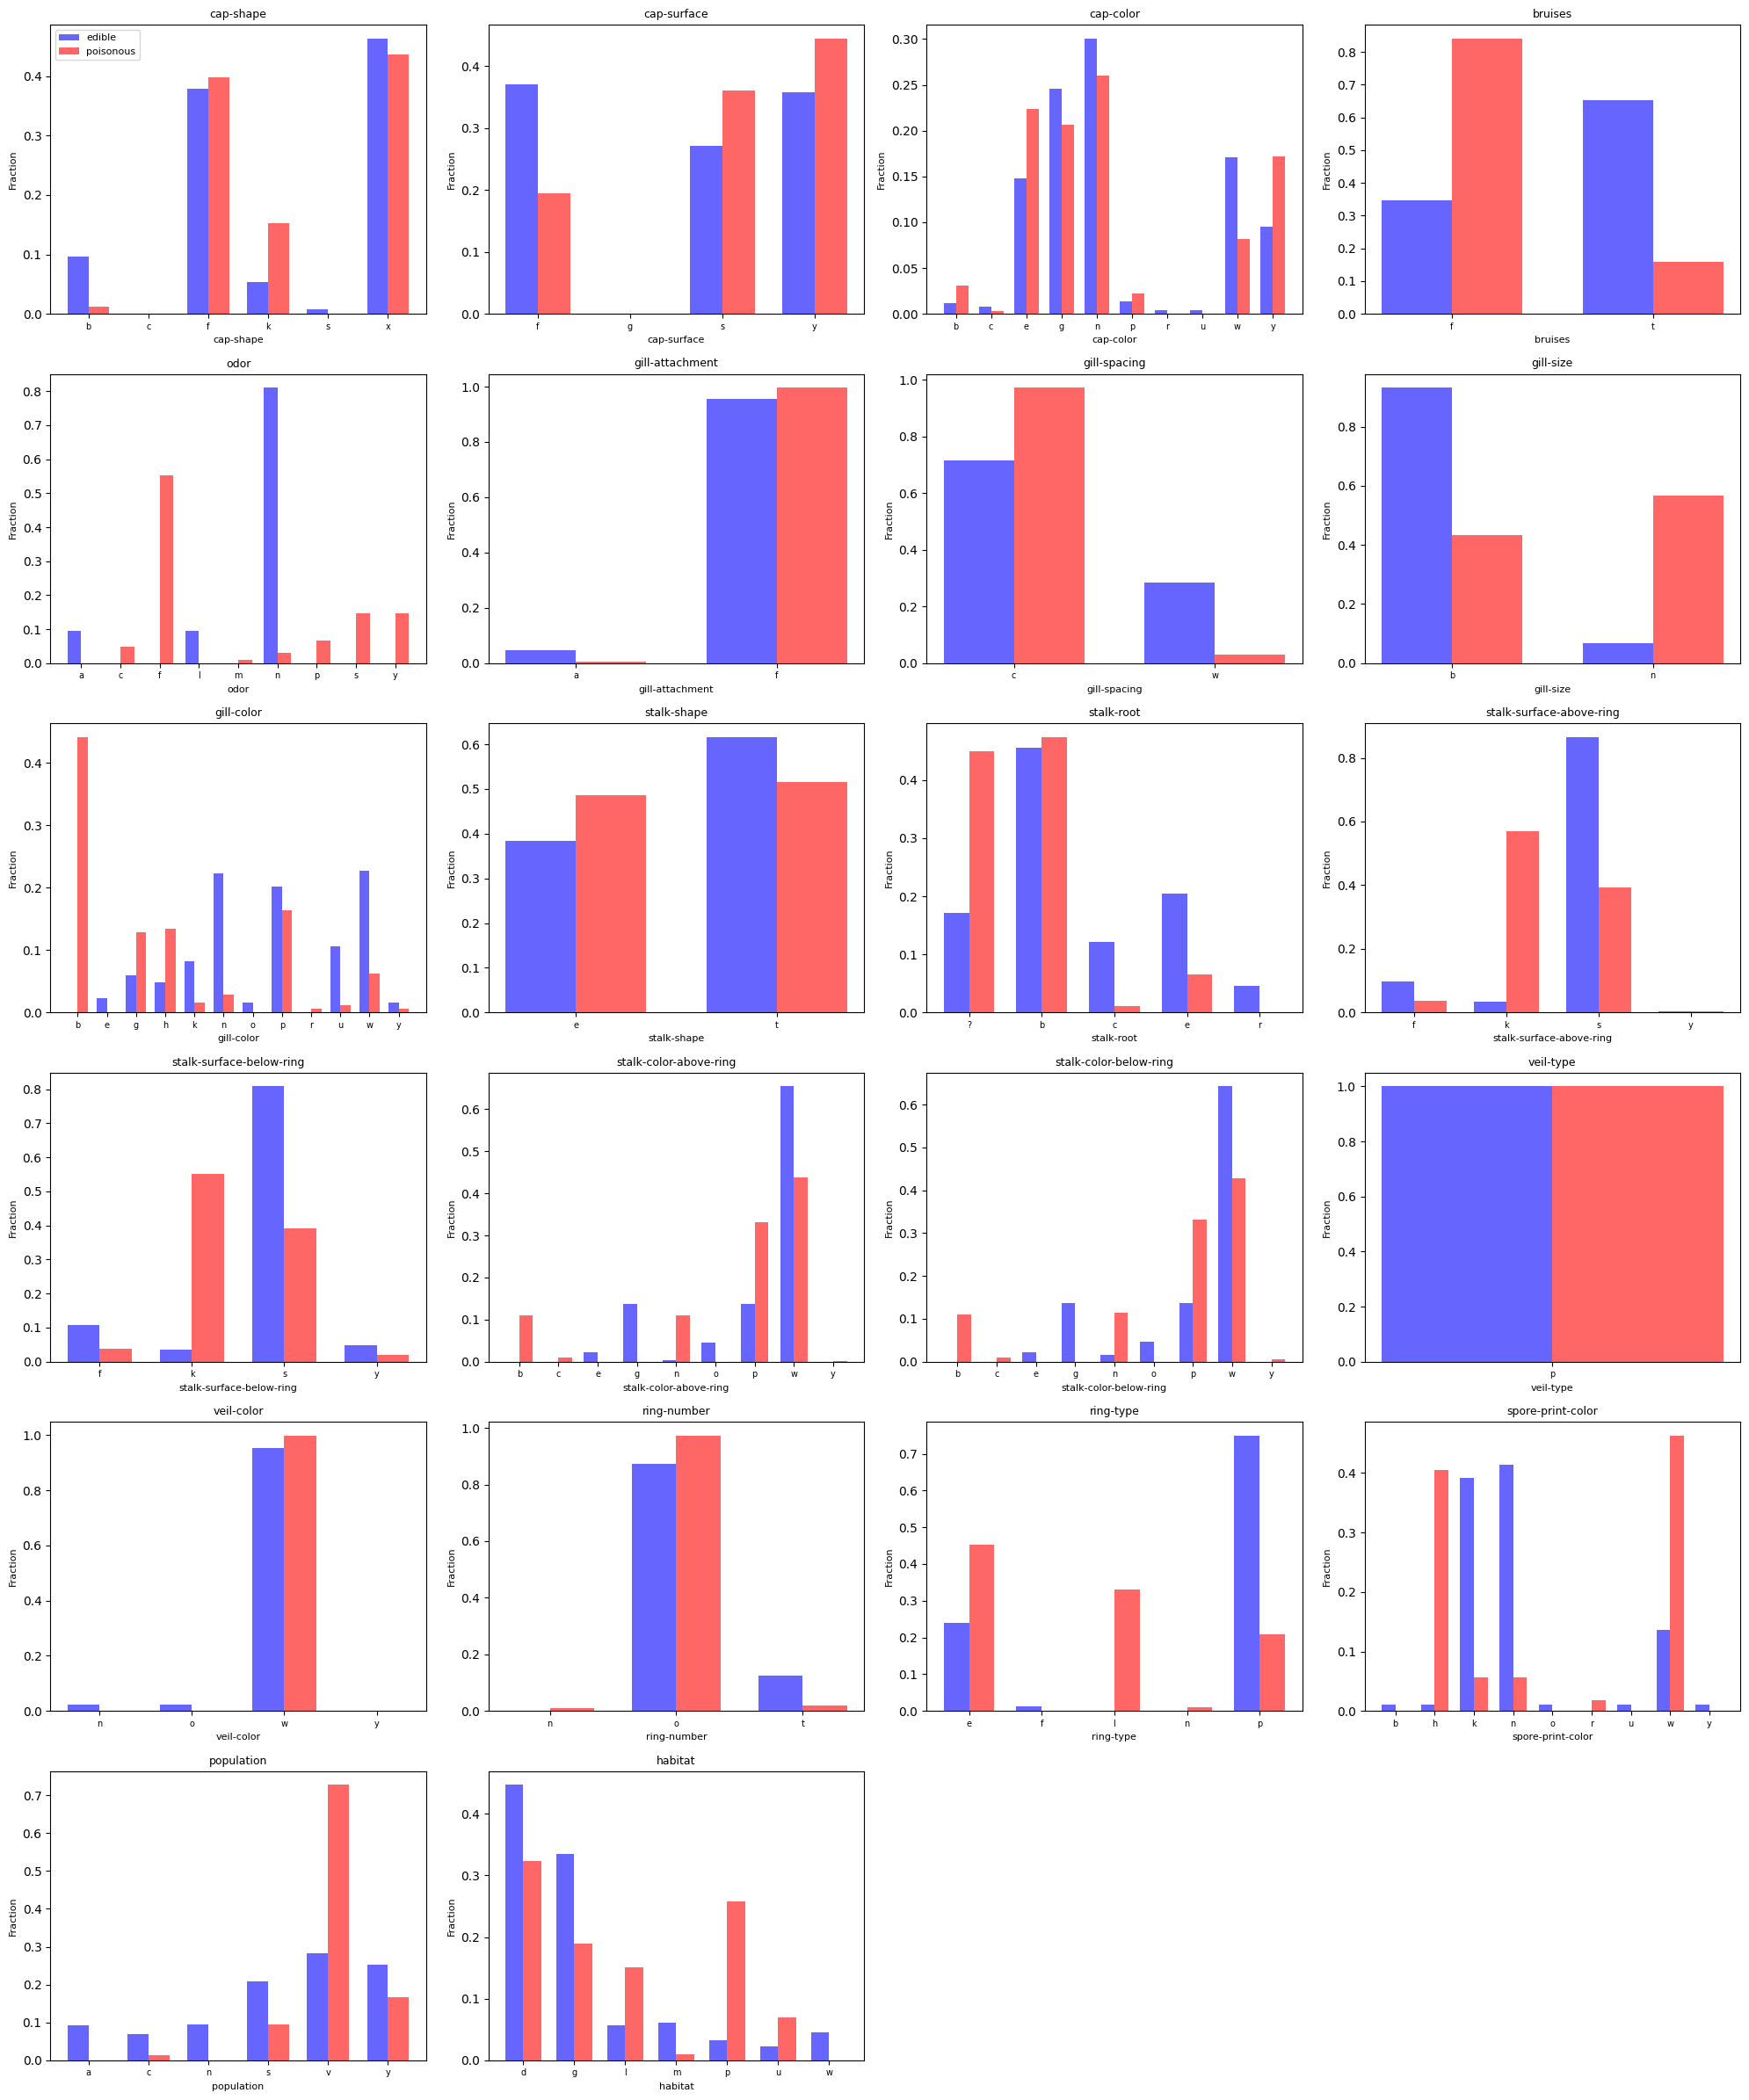

In [35]:
# Display all feature distributions in a grid for compact viewing
features = [col for col in df.columns if col != "class"]

N_cols = 4
N_rows = math.ceil(len(features) / N_cols)

plt.figure(figsize=(20, N_rows * 4))

for i, col in enumerate(features):
    edible_counts    = df_edible[col].value_counts(normalize=True).sort_index()
    poisonous_counts = df_poisonous[col].value_counts(normalize=True).sort_index()
    all_cats = sorted(set(edible_counts.index) | set(poisonous_counts.index))

    x = np.arange(len(all_cats))
    width = 0.35

    plt.subplot(N_rows, N_cols, i + 1)
    plt.bar(x - width/2, [edible_counts.get(c, 0) for c in all_cats],    width, color="blue", alpha=0.6, label="edible")
    plt.bar(x + width/2, [poisonous_counts.get(c, 0) for c in all_cats], width, color="red",  alpha=0.6, label="poisonous")
    plt.xticks(x, all_cats, fontsize=7)
    plt.xlabel(col, fontsize=8)
    plt.ylabel("Fraction", fontsize=8)
    plt.title(col, fontsize=9)
    if i == 0:
        plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [36]:
# For each feature, display a table showing the count of each category
# for edible vs poisonous — categorical equivalent of a histogram

for col in features:
    edible_counts    = df_edible[col].value_counts().sort_index()
    poisonous_counts = df_poisonous[col].value_counts().sort_index()
    all_cats = sorted(set(edible_counts.index) | set(poisonous_counts.index))

    table = []
    for c in all_cats:
        e_count = edible_counts.get(c, 0)
        p_count = poisonous_counts.get(c, 0)
        table.append((c, e_count, p_count))

    print(f"\n{col}")
    display(HTML(tabulate.tabulate(table, tablefmt="html",
                                   headers=["Category", "Edible", "Poisonous"])))


cap-shape


Category,Edible,Poisonous
b,404,48
c,0,4
f,1596,1556
k,228,600
s,32,0
x,1948,1708



cap-surface


Category,Edible,Poisonous
f,1560,760
g,0,4
s,1144,1412
y,1504,1740



cap-color


...

Category,Edible,Poisonous
b,48,0
h,48,1584
k,1648,224
n,1744,224
o,48,0
r,0,72
u,48,0
w,576,1812
y,48,0



population


Category,Edible,Poisonous
a,384,0
c,288,52
n,400,0
s,880,368
v,1192,2848
y,1064,648



habitat


Category,Edible,Poisonous
d,1880,1268
g,1408,740
l,240,592
m,256,36
p,136,1008
u,96,272
w,192,0


## Observations

- **odor** is by far the strongest separator — poisonous mushrooms concentrate 
  in foul (f), creosote (c), pungent (p) odors while edible are mostly none (n) or almond (a).

- **spore-print-color**, **gill-color**, and **ring-type** also show strong differences 
  between classes and will likely be useful for ML.

- **bruises**, **stalk-surface-above-ring**, and **stalk-surface-below-ring** show 
  moderate separation.

- **veil-type** has only one unique value across all samples — it carries no 
  information and will be dropped in cleaning.

- **stalk-root** has missing values encoded as '?' which appear predominantly 
  in poisonous mushrooms — worth noting as we handle this in cleaning.

- **gill-attachment** and **gill-spacing** show very similar distributions between 
  classes — likely less useful for ML.

## Data Cleaning and Preparation for Machine Learning

In [37]:
# Drop veil-type — only one unique value across all samples, carries no information
df_clean = df.drop(columns=["veil-type"])
print("Columns after dropping veil-type:", df_clean.shape[1])

Columns after dropping veil-type: 22


In [51]:
# Handle missing values in stalk-root encoded as '?'
# Replace with mode
print("stalk-root value counts before cleaning:")
print(df_clean["stalk-root"].value_counts())

df_clean["stalk-root"] = df_clean["stalk-root"].replace("?", df_clean["stalk-root"].mode()[0])

print("\nstalk-root value counts after cleaning:")
print(df_clean["stalk-root"].value_counts())

stalk-root value counts before cleaning:
stalk-root
b    6256
e    1120
c     556
r     192
Name: count, dtype: int64

stalk-root value counts after cleaning:
stalk-root
b    6256
e    1120
c     556
r     192
Name: count, dtype: int64


In [39]:
# Encode target variable: edible=0, poisonous=1
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_clean["class"] = le.fit_transform(df_clean["class"])

print("Target encoding:", dict(zip(le.classes_, le.transform(le.classes_))))
print(df_clean["class"].value_counts())

Target encoding: {'e': np.int64(0), 'p': np.int64(1)}
class
0    4208
1    3916
Name: count, dtype: int64


In [40]:
# Note on rescaling: since all features are categorical, numerical rescaling
# (e.g. MinMaxScaler, StandardScaler) is not applicable here.
# One-hot encoding will convert all features into binary numerical columns.

# One-hot encode all categorical features
from sklearn.preprocessing import OneHotEncoder

features_to_encode = [col for col in df_clean.columns if col != "class"]

encoder = OneHotEncoder(sparse_output=False)
encoded_array = encoder.fit_transform(df_clean[features_to_encode])

# Put encoded features into a dataframe with proper column names
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(features_to_encode))

print("Shape before encoding:", df_clean[features_to_encode].shape)
print("Shape after encoding: ", encoded_df.shape)
encoded_df.head()

Shape before encoding: (8124, 21)
Shape after encoding:  (8124, 115)


,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [41]:
# Combine encoded features with target to form final cleaned dataset
df_final = pd.concat([encoded_df, df_clean["class"].reset_index(drop=True)], axis=1)

print("Final dataset shape:", df_final.shape)
df_final.head()

Final dataset shape: (8124, 116)


,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,...,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w,class
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0


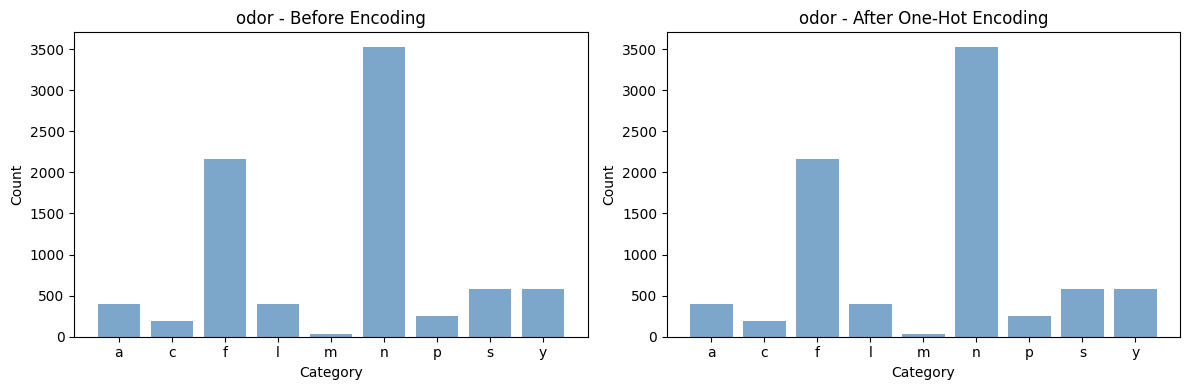

In [52]:
# Visualize a few features before and after one-hot encoding to show the transformation

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before — raw categorical counts for odor
odor_counts = df_clean["odor"].value_counts().sort_index()
axes[0].bar(odor_counts.index, odor_counts.values, color="steelblue", alpha=0.7)
axes[0].set_title("odor - Before Encoding")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Count")

# After — one-hot encoded odor columns
odor_cols = [col for col in encoded_df.columns if col.startswith("odor")]
odor_sums = encoded_df[odor_cols].sum().sort_index()
axes[1].bar([c.split("_")[-1] for c in odor_sums.index], odor_sums.values, color="steelblue", alpha=0.7)
axes[1].set_title("odor - After One-Hot Encoding")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## Data Cleaning and Preparation — Summary

- **veil-type** was dropped as it contained only one unique value across all 8,124 samples, 
  making it completely uninformative for any ML model.

- **stalk-root** had 2,480 missing values encoded as '?'. These were replaced with the 
  most frequent value (mode) as a simple imputation strategy. More sophisticated approaches 
  such as predicting the missing values from other features exist, but mode imputation is 
  sufficient here.

- **Target encoding**: the class label was converted from letters (e/p) to binary 
  integers (edible=0, poisonous=1).

- **Rescaling**: since all features in this dataset are categorical, numerical rescaling 
  strategies such as MinMaxScaler or StandardScaler are not applicable and were not applied.

- **One-hot encoding**: all 21 remaining categorical features were one-hot encoded, 
  expanding the dataset from 21 columns to ~95 binary columns. The before/after 
  visualization confirms that encoding preserves the original category counts — 
  only the data structure changes, not the underlying information.

## MACHINE LEARNING

In [43]:
#PROBLEM FORMATION

In [44]:
# Remove target from features and set up X and y
X = df_final.drop(columns=["class"])
y = df_final["class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8124, 115)
y shape: (8124,)


In [45]:
# Shuffle dataset before splitting to ensure representative train/test sets
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

X = df_final.drop(columns=["class"])
y = df_final["class"]

N_total = X.shape[0]
N_train = math.floor(0.8 * N_total)

X_train = X[:N_train]
y_train = y[:N_train]

X_test  = X[N_train:]
y_test  = y[N_train:]

print("Train size:", N_train)
print("Test size: ", N_total - N_train)

Train size: 6499
Test size:  1625


In [46]:
#TRAIN ML ALGORITHM

In [47]:
# Train a Decision Tree classifier — a natural choice for categorical data
# Decision trees partition the feature space using simple rules, making them
# highly interpretable and well suited to this type of dataset
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

Training complete.


In [48]:
# Evaluate performance on test sample using standard classification metrics
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_curve, auc)

y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:, 1]

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

display(HTML(tabulate.tabulate(
    [["Accuracy",  f"{accuracy:.4f}"],
     ["Precision", f"{precision:.4f}"],
     ["Recall",    f"{recall:.4f}"],
     ["F1 Score",  f"{f1:.4f}"],
     ["AUC",       f"{roc_auc:.4f}"]],
    tablefmt="html", headers=["Metric", "Value"])))

Metric,Value
Accuracy,1
Precision,1
Recall,1
F1 Score,1
AUC,1


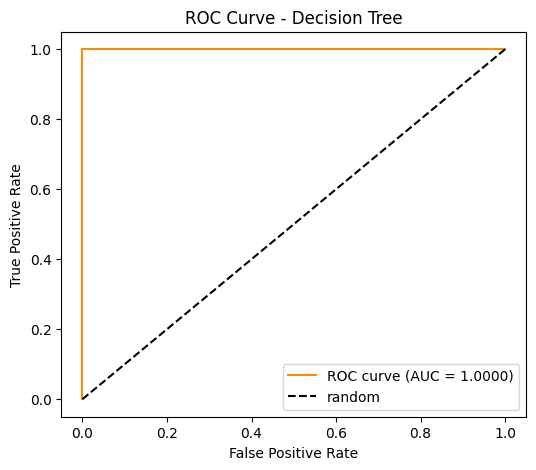

In [49]:
# ROC curve on test sample
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="darkorange", label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend(loc="lower right")
plt.show()

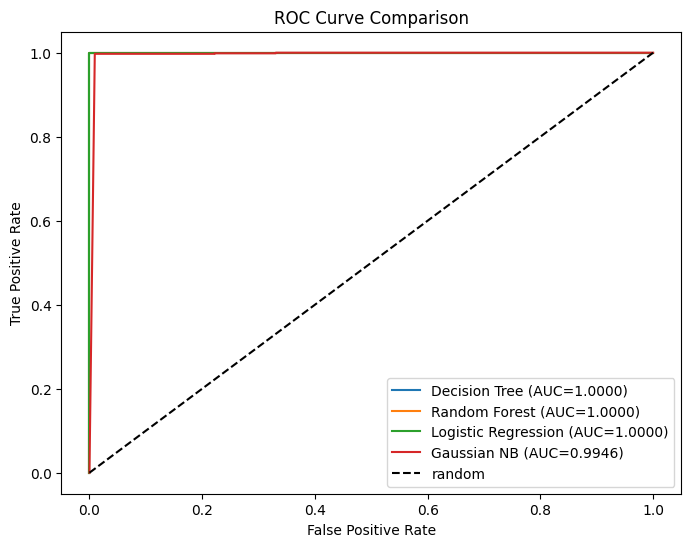

Classifier,Accuracy,F1 Score,AUC
Decision Tree,1,1,1
Random Forest,1,1,1
Logistic Regression,0.9994,0.9994,1
Gaussian NB,0.9569,0.9568,0.9946


In [50]:
# Compare additional classifiers against the Decision Tree
# Using the same train/test split for fair comparison
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_curve, auc

classifiers = {
    "Decision Tree":      DecisionTreeClassifier(random_state=42),
    "Random Forest":      RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Gaussian NB":        GaussianNB(),
}

results = []
plt.figure(figsize=(8, 6))

for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    # Use predict_proba for ROC curve
    y_prob = clf.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    f1       = f1_score(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc  = auc(fpr, tpr)

    results.append((name, f"{accuracy:.4f}", f"{f1:.4f}", f"{roc_auc:.4f}"))
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", label="random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.show()

# Summary table of all classifiers
display(HTML(tabulate.tabulate(results, tablefmt="html",
                               headers=["Classifier", "Accuracy", "F1 Score", "AUC"])))